### Сбор данных

Тематика исследования: влияние различных факторов на продолжительность утренних сборов перед учебой/работой.

Входные данные:

| Признак | Тип данных | Шкала данных |
| :--- | :--- | :--- |
| Пол | Бинарный | Номинальная |
| Возраст | Числовой | Отношений |
| Куда респондент собирается утром | Бинарный | Номинальная |
| Время выхода из дома | Время | Интервальная |
| Есть ли сожители | Бинарный | Номинальная |
| Выходят ли все сожители одновременно | Бинарный | Номинальная |
| Действия перед выходом | Множественный выбор | Интервальная |
| Собран ли рюкзак/сумка с вечера | Бинарный | Порядковая |
| Приходится ли искать какие-то вещи | Категориальный | Порядковая |
| Сколько раз откладывается будильник | Категориальный | Порядковая |
| Время утренних сборов (минуты) | Числовой | Отношений |

В качестве метода сбора был выбран опрос-анкетирование с помощью Google Forms, так как это удобный способ как для прохождения опроса, так и для анализа полученных результатов. В сервисе имеются готовые инструменты для анализа полученных ответов, в частности визуализация данных.


Вопросы для анкеты выбраны следующие:

1. Ваш пол (Мужской/Женский)

2. Ваш возраст

3. Куда собираетесь утром? (На учебу/На работу)

4. Во сколько выходите из дома?

5. Живете ли совместно с кем-то? (Да/Нет)

6. Выходят ли все члены семьи одновременно? (Да/Нет)

7. Отметьте, что вы обязательно делаете перед выходом (Варианты: Душ/умывание; Завтрак (с нуля); Завтрак (разогреть готовый); Готовка обеда с собой; Макияж; Общение с семьей; Зарядка/разминка; Выгул собаки; Проверка телефона (сообщение, новости, почта))

8. Собираете ли вы сумку/рюкзак с вечера? (Да/Нет/Иногда)

9. Бывает ли так, что вы ищете вещи утром (ключи, телефон, зарядку и т. д.)? (Почти никогда/Редко/Часто/Почти всегда)

10. Сколько раз откладываете будильник? (0/1/2-3/4 и более)

11. Сколько минут занимают утренние сборы?

На момент создания отчета опрос прошли 60 респондентов. С момента публикации опроса прошло менее суток.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/survey.csv")
df.sample(5)

,Отметка времени,Ваш пол,Ваш возраст (лет),Куда вы обычно собираетесь утром?,"Во сколько вы должны выйти, чтобы не опоздать?",Живете ли совместно с кем-то?,Выходят ли из дома все члены семьи одновременно?,"Отметьте, что вы обязательно делаете перед выходом",Собираете ли вы сумку/рюкзак с вечера?,"Бывает ли так, что вы ищете вещи утром (ключи, телефон, зарядку и т. д.)?",Сколько раз откладываете будильник?,Сколько минут занимают утренние сборы (от пробуждения до выхода из дома)?
9,2026/04/15 3:46:55 PM GMT+5,Женский,19,На учебу,07:00,Да,Нет,Душ/умывание;Завтрак (с нуля);Общение с семьей...,Да,Почти никогда,4 и более,60.0
49,2026/04/15 9:29:44 PM GMT+5,Мужской,20,На учебу,07:35,Да,Да,"Завтрак (с нуля);Проверка телефона (сообщения,...",Да,Почти никогда,0,45.0
27,2026/04/15 5:21:00 PM GMT+5,Мужской,21,На учебу,07:00,Да,Нет,"Проверка телефона (сообщения, новости, почта и...",Да,Редко,0,30.0
38,2026/04/15 6:48:07 PM GMT+5,Мужской,21,На учебу,10:00,Нет,Да,Душ/умывание;Завтрак (с нуля);Проверка телефон...,Нет,Редко,2-3,60.0
2,2026/04/15 3:23:33 PM GMT+5,Мужской,18,На работу,07:30,Да,Нет,"Душ/умывание;Проверка телефона (сообщения, нов...",Да,Редко,1,10.0


In [5]:
df = df.rename(columns={"Ваш пол": "Пол",
                   "Ваш возраст (лет)": "Возраст",
                   "Куда вы обычно собираетесь утром?": "Работа/Учеба",
                   "Во сколько вы должны выйти, чтобы не опоздать?": "Время выхода",
                   "Живете ли совместно с кем-то?": "Сожители",
                   "Выходят ли из дома все члены семьи одновременно?": "Одновременный выход сожителей",
                   "Отметьте, что вы обязательно делаете перед выходом": "Список дел",
                   "Собираете ли вы сумку/рюкзак с вечера?": "Сбор вещей с вечера",
                   "Бывает ли так, что вы ищете вещи утром (ключи, телефон, зарядку и т. д.)?": "Поиск вещей",
                   "Сколько раз откладываете будильник?": "Откладывание будильника"})

Посмотрим визуализацию результатов опроса:

c:\Projects\ml-uust\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)                                     



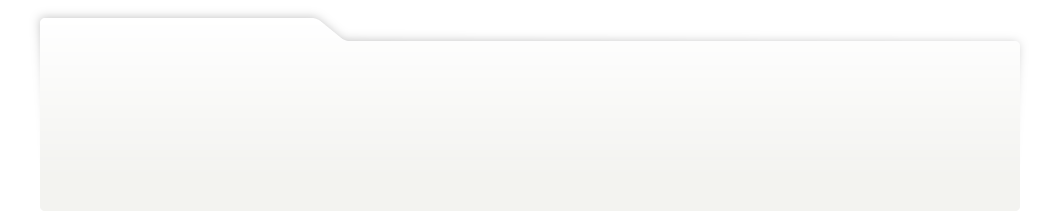
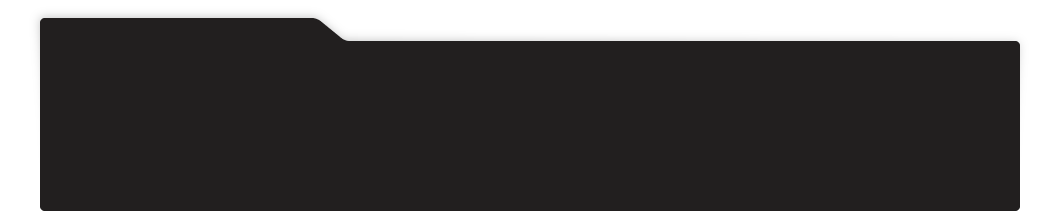
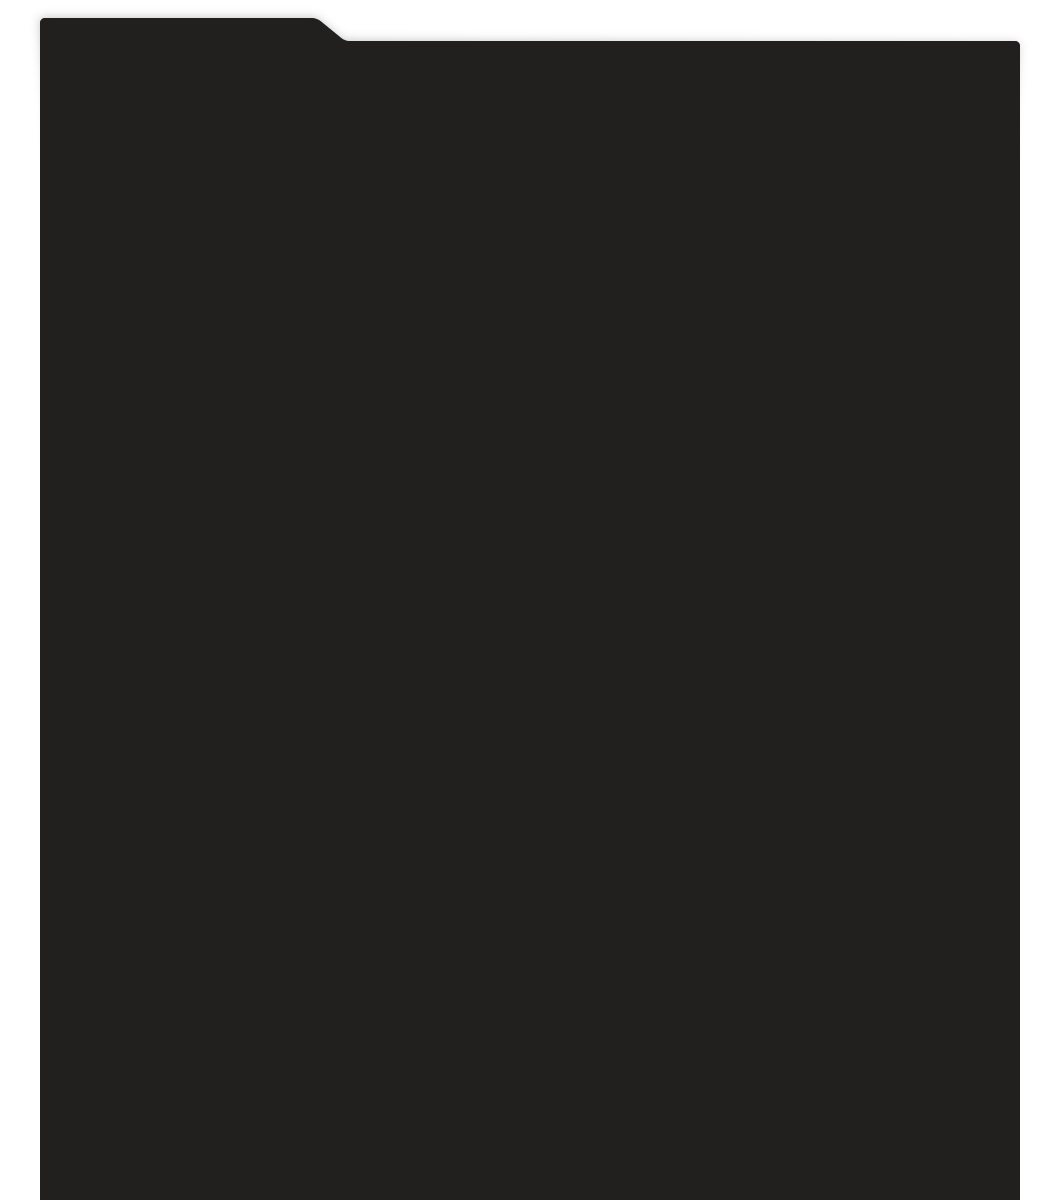
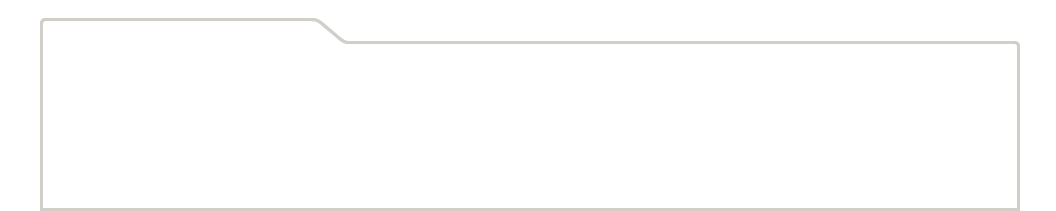
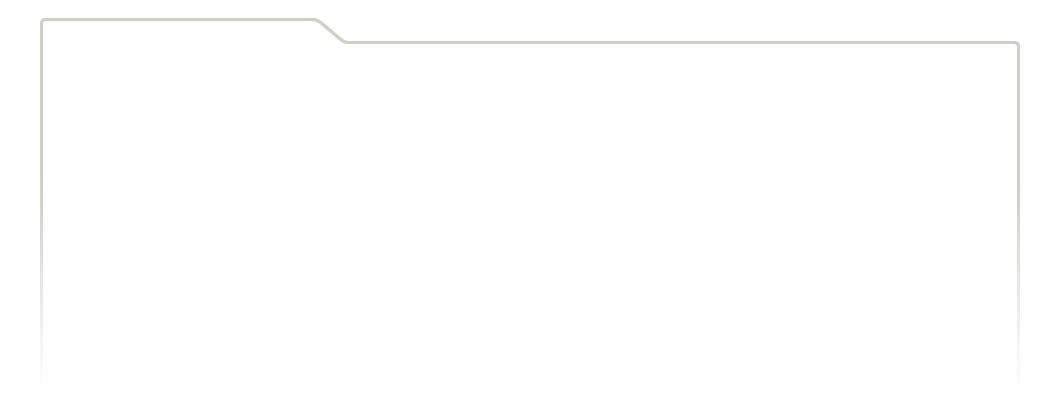
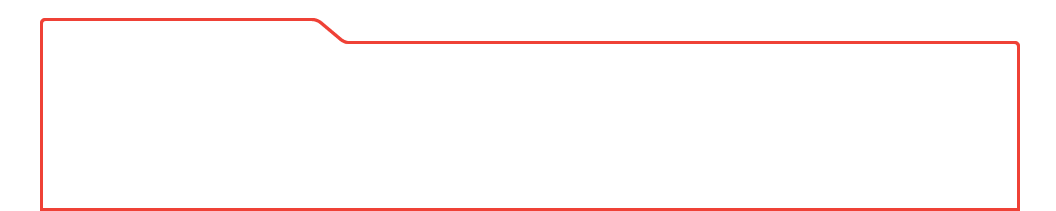
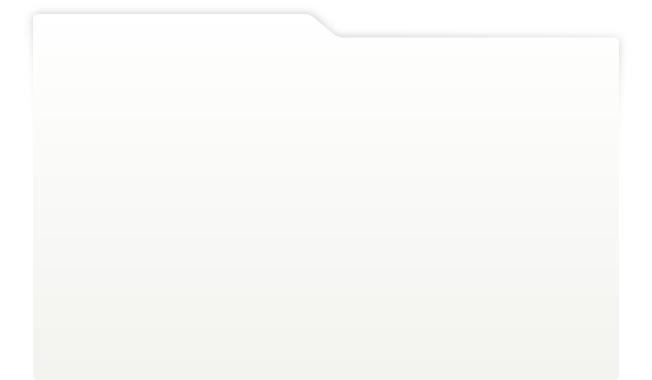
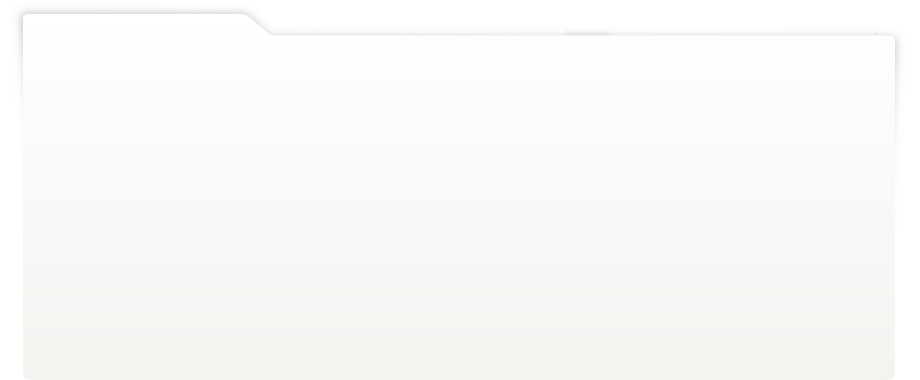
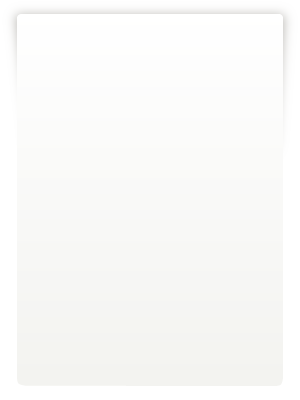
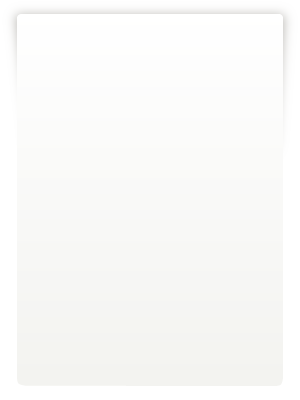
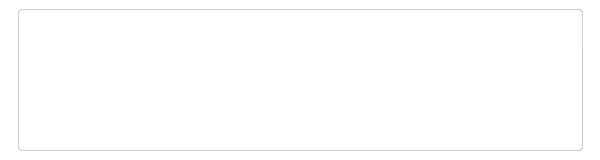
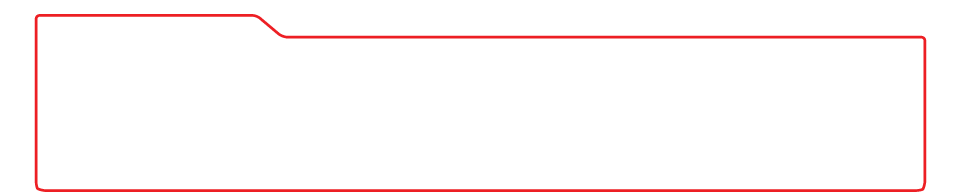
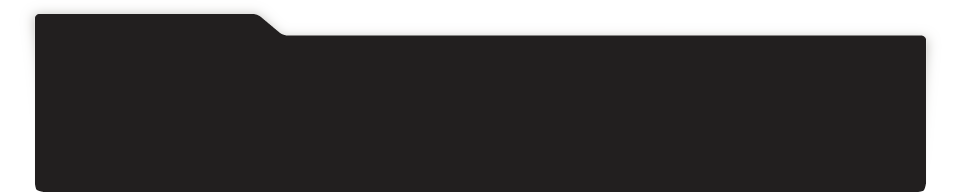
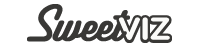
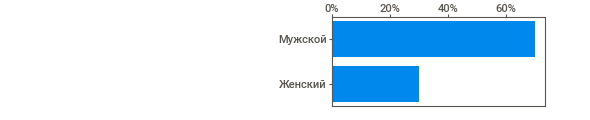
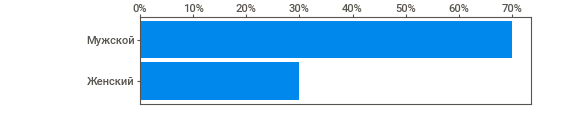
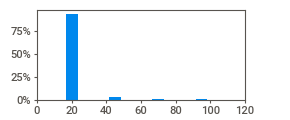
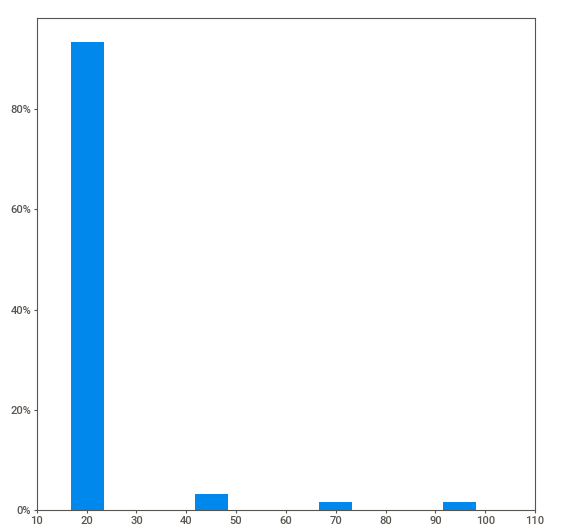
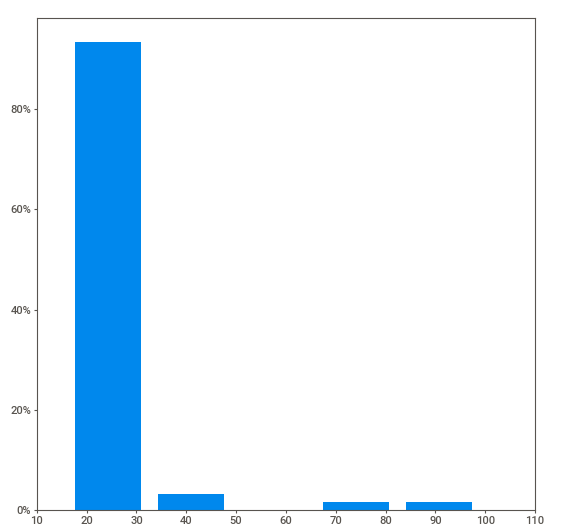
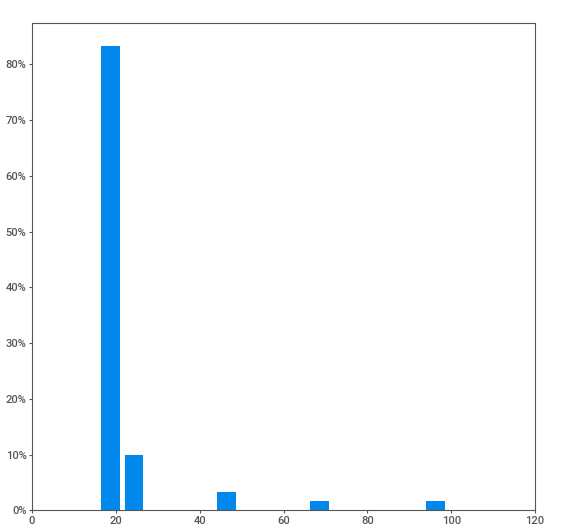
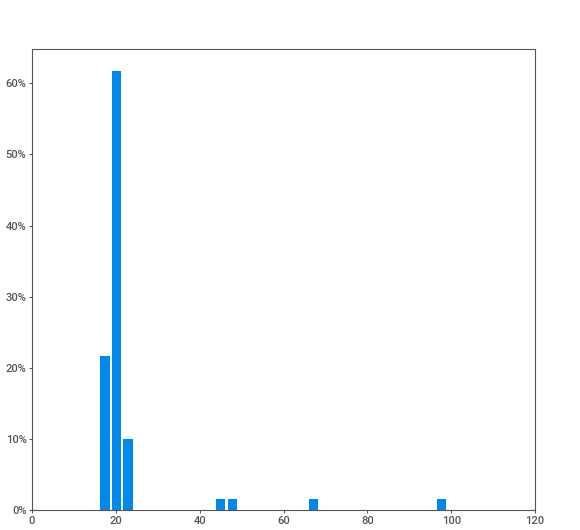
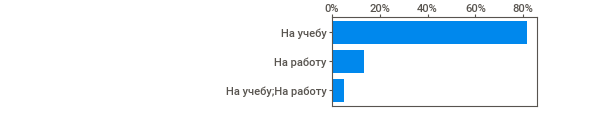
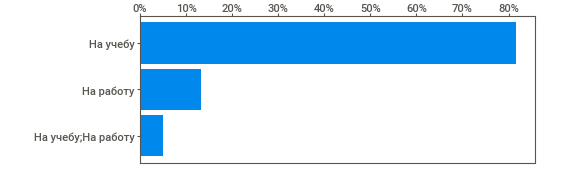
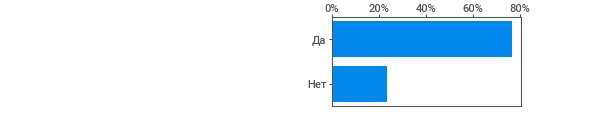
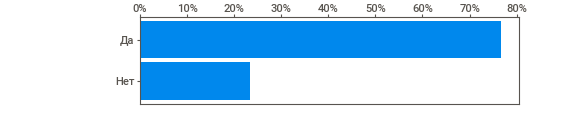
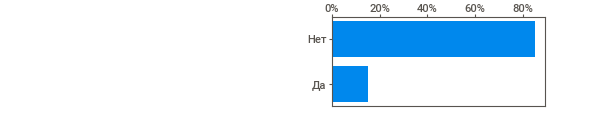
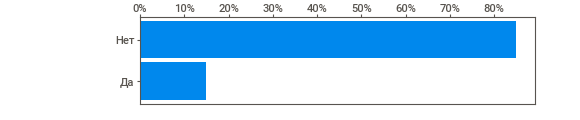
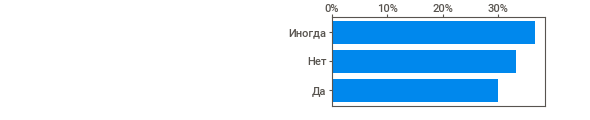
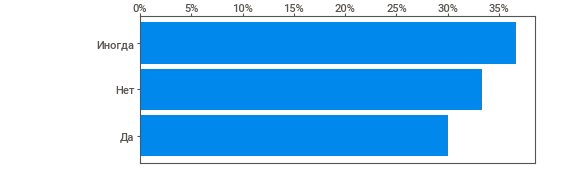
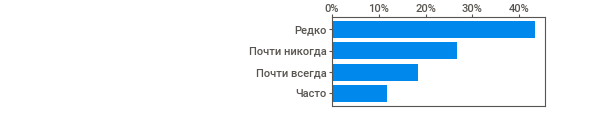
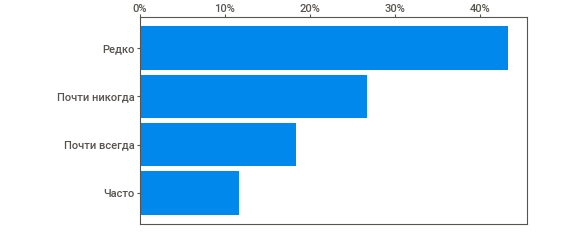
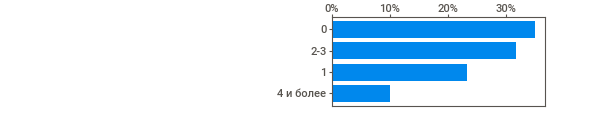
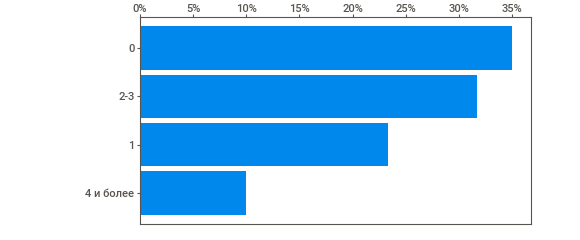
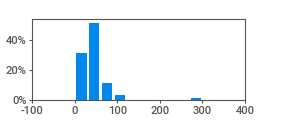
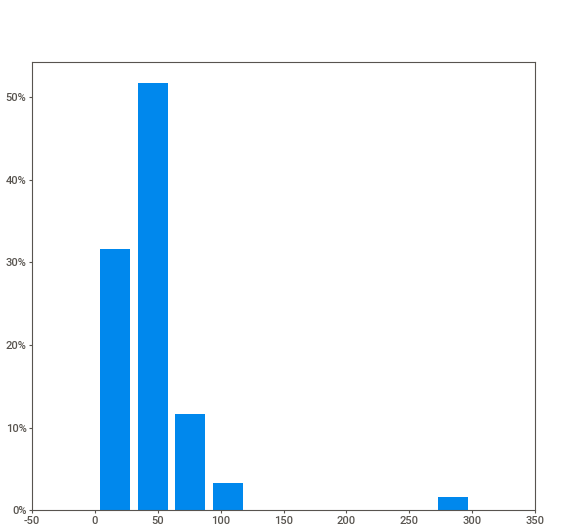
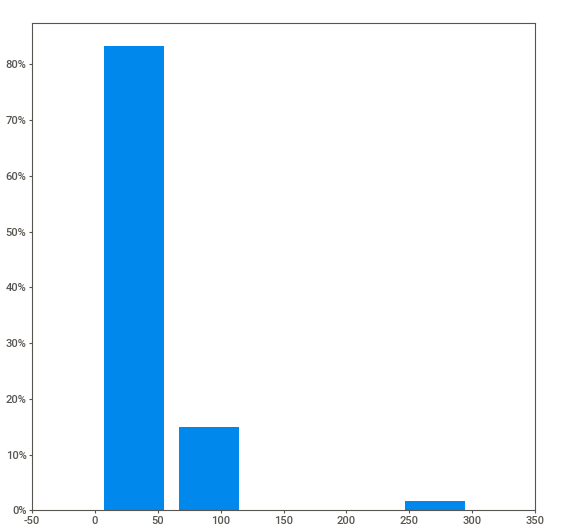
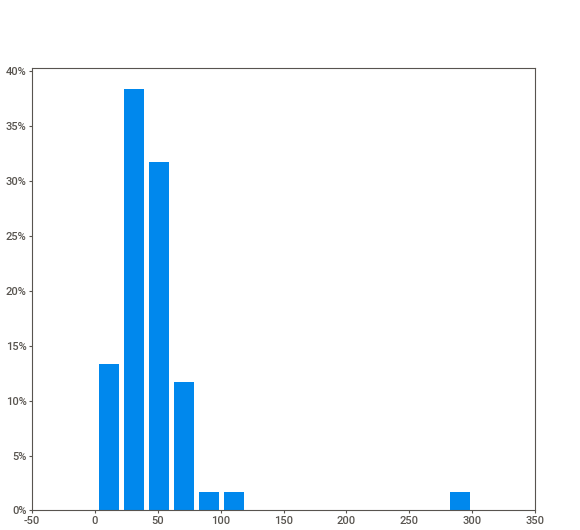
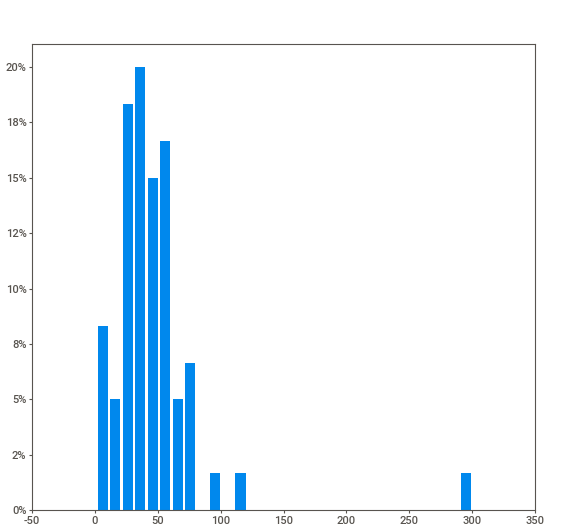
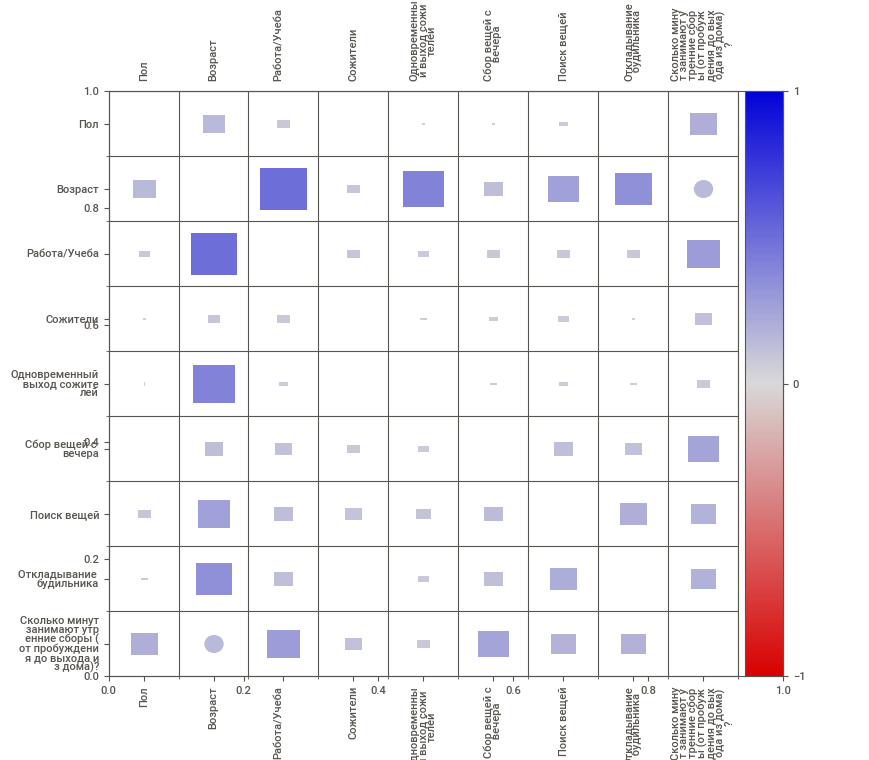
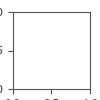

In [14]:
import sweetviz as sv

report = sv.analyze(df)
report.show_notebook()

In [15]:
report.show_html('titanic_report.html', open_browser=True)

Report titanic_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Выводы по результатам опроса:

- В исследовании приняли участие 60 человек, при этом пропущенные значения отсутствуют, что делает результаты надёжными для анализа.

- Среднее время утренних сборов составляет около 60 минут, что можно считать типичным значением для выборки.

- Наибольшее влияние на продолжительность сборов оказывает цель выхода (работа или учёба), что указывает на важность контекста повседневной деятельности.

- Существенным фактором является одновременный выход сожителей — совместное проживание и необходимость синхронизации увеличивают время сборов.

- Поведенческие привычки, такие как откладывание будильника, заметно увеличивают длительность утренних сборов.

- Поиск необходимых вещей утром также приводит к увеличению времени сборов, что говорит о важности предварительной подготовки.

- Пол респондента практически не влияет на продолжительность утренних сборов.

- Сбор вещей с вечера оказывает слабое влияние, но может незначительно сокращать время сборов.

- Сам факт наличия сожителей почти не влияет на длительность сборов, в отличие от их поведения (например, одновременного выхода).

- Откладывание будильника частично связано с возрастом и в небольшой степени влияет на увеличение времени сборов.

- В целом продолжительность утренних сборов определяется преимущественно поведенческими и социальными факторами, а не демографическими характеристиками.